In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import pickle

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

%matplotlib inline

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [3]:
# Option A: Upload manually
from google.colab import files
uploaded = files.upload()  # upload spam.csv (SMS Spam Collection dataset from Kaggle/UCI)

df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

Saving spam.csv to spam.csv


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
# Option B: If your CSV has extra unnamed columns (common with this dataset)
df = df[['v1', 'v2']]
df.columns = ['target', 'text']
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
print(df.shape)
df.info()
print(df['target'].value_counts())
print(df.isnull().sum())
print(df.duplicated().sum())

(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
target
ham     4825
spam     747
Name: count, dtype: int64
target    0
text      0
dtype: int64
403


In [6]:
# Remove duplicates
df = df.drop_duplicates(keep='first')

# Encode target: ham=0, spam=1
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

print(df['target'].value_counts())
print(df.shape)

target
0    4516
1     653
Name: count, dtype: int64
(5169, 2)


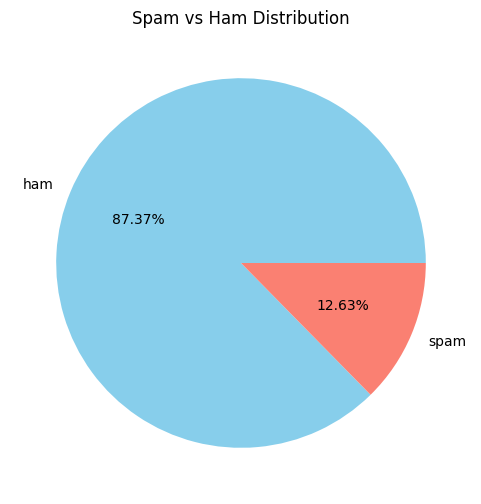

In [7]:
plt.figure(figsize=(6,6))
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct='%0.2f%%', colors=['skyblue','salmon'])
plt.title('Spam vs Ham Distribution')
plt.show()

In [8]:
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


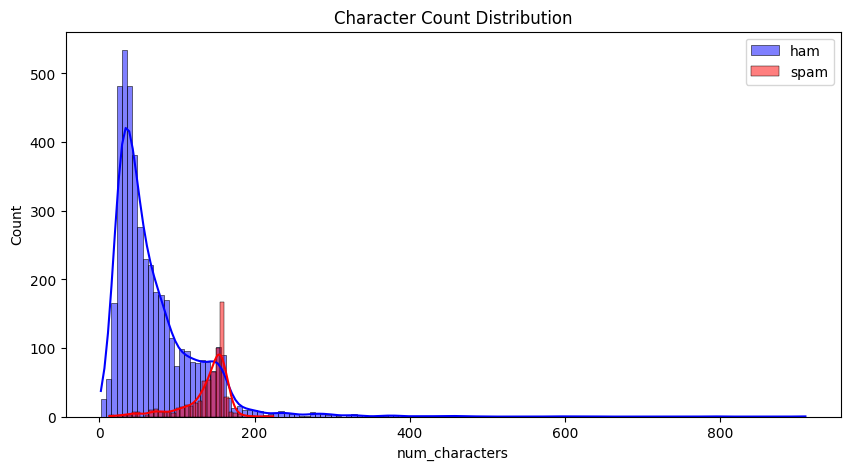

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df[df['target']==0]['num_characters'], color='blue', label='ham', kde=True)
sns.histplot(df[df['target']==1]['num_characters'], color='red', label='spam', kde=True)
plt.legend()
plt.title('Character Count Distribution')
plt.show()

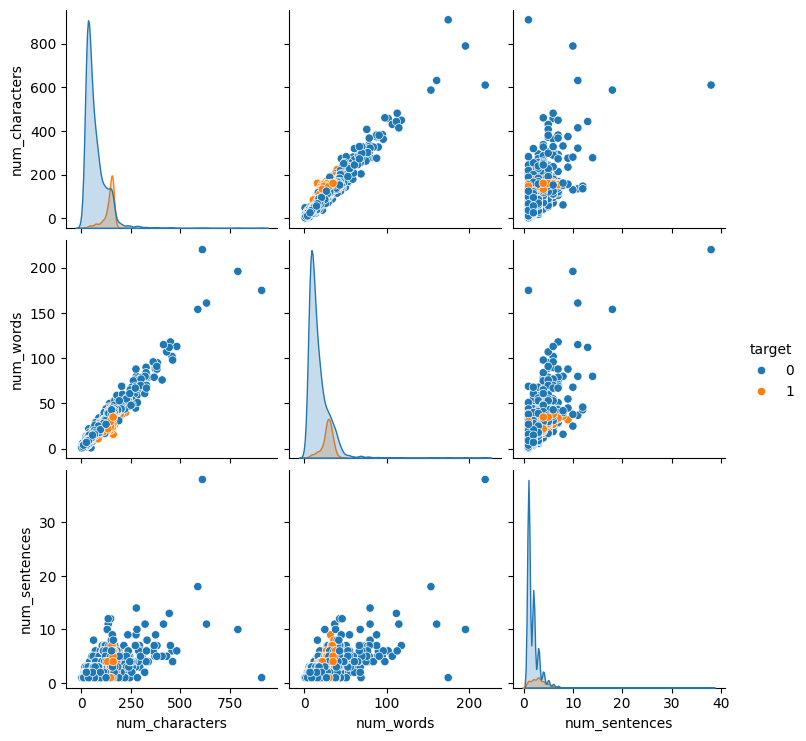

In [10]:
sns.pairplot(df, hue='target', vars=['num_characters','num_words','num_sentences'])
plt.show()

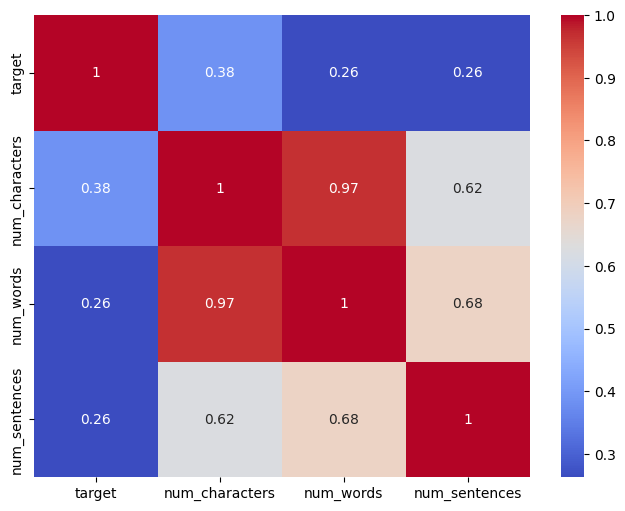

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['target','num_characters','num_words','num_sentences']].corr(), annot=True, cmap='coolwarm')
plt.show()

In [12]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def transform_text(text):
    text = text.lower()                                  # lowercase
    text = re.sub(r'<.*?>', '', text)                     # remove HTML
    text = re.sub(r'http\S+|www\S+', '', text)            # remove URLs
    text = re.sub(r'\d+', '', text)                        # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation

    tokens = nltk.word_tokenize(text)                      # tokenization

    tokens = [word for word in tokens if word not in stop_words]  # stopword removal

    tokens = [ps.stem(word) for word in tokens]             # stemming

    return " ".join(tokens)

df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah dont think goe usf live around though


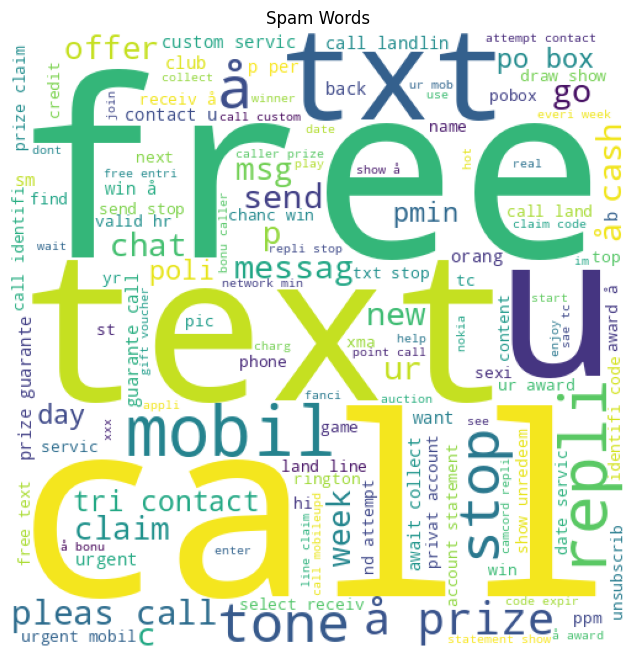

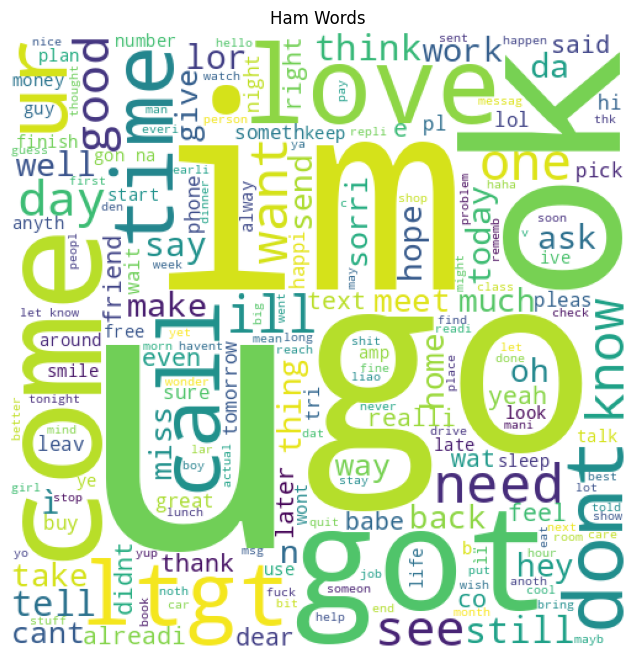

In [13]:
# Wordclouds (optional visualization)
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(8,8))
plt.imshow(spam_wc)
plt.title("Spam Words")
plt.axis('off')
plt.show()

ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(8,8))
plt.imshow(ham_wc)
plt.title("Ham Words")
plt.axis('off')
plt.show()

In [14]:
# Already created num_characters, num_words, num_sentences above (Step 5)
# These can optionally be combined with TF-IDF features later
df[['num_characters','num_words','num_sentences']].head()

,num_characters,num_words,num_sentences
0,111,24,2
1,29,8,2
2,155,37,2
3,49,13,1
4,61,15,1


In [15]:
cv = CountVectorizer(max_features=3000)
X_cv = cv.fit_transform(df['transformed_text']).toarray()

tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(df['transformed_text']).toarray()

y = df['target'].values

print(X_cv.shape, X_tfidf.shape)

(5169, 3000) (5169, 3000)


In [16]:
# Using TF-IDF (generally performs better for this task)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(4135, 3000) (1034, 3000)


In [17]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(kernel='sigmoid', gamma=1.0, probability=True),
    'KNN': KNeighborsClassifier(),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

Naive Bayes trained.
Logistic Regression trained.
Random Forest trained.
Decision Tree trained.
SVM trained.
KNN trained.
Extra Trees trained.



Naive Bayes
Accuracy: 0.9749 | Precision: 1.0000 | Recall: 0.8207 | F1: 0.9015


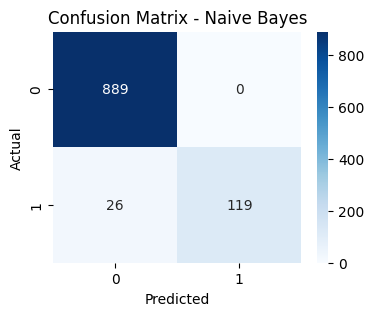


Logistic Regression
Accuracy: 0.9526 | Precision: 0.9444 | Recall: 0.7034 | F1: 0.8063


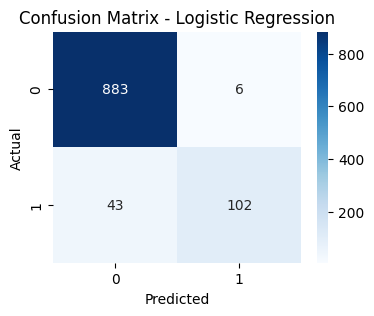


Random Forest
Accuracy: 0.9700 | Precision: 0.9914 | Recall: 0.7931 | F1: 0.8812


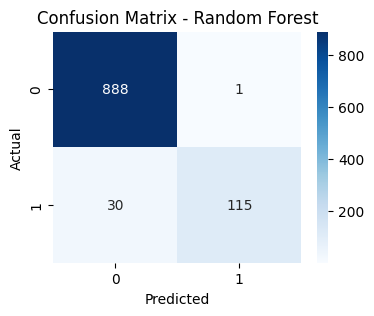


Decision Tree
Accuracy: 0.9526 | Precision: 0.8333 | Recall: 0.8276 | F1: 0.8304


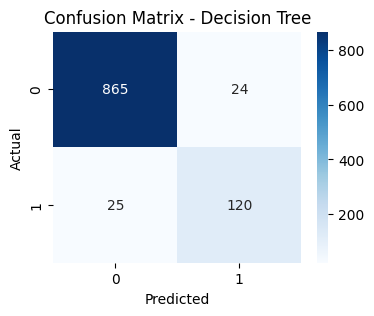


SVM
Accuracy: 0.9729 | Precision: 0.9398 | Recall: 0.8621 | F1: 0.8993


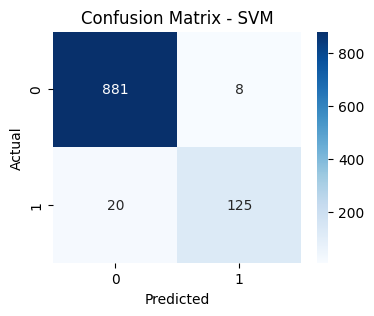


KNN
Accuracy: 0.9081 | Precision: 1.0000 | Recall: 0.3448 | F1: 0.5128


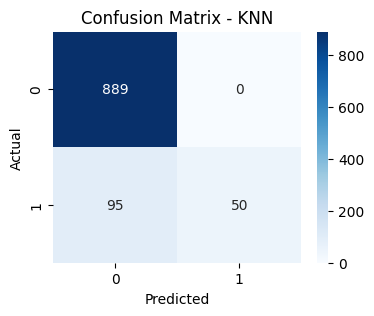


Extra Trees
Accuracy: 0.9778 | Precision: 0.9841 | Recall: 0.8552 | F1: 0.9151


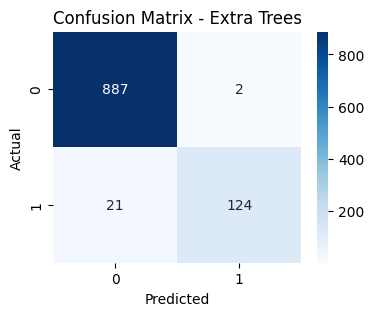

In [18]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1})

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.974855   1.000000  0.820690  0.901515
5                  KNN  0.908124   1.000000  0.344828  0.512821
2        Random Forest  0.970019   0.991379  0.793103  0.881226
6          Extra Trees  0.977756   0.984127  0.855172  0.915129
1  Logistic Regression  0.952611   0.944444  0.703448  0.806324
4                  SVM  0.972921   0.939850  0.862069  0.899281
3        Decision Tree  0.952611   0.833333  0.827586  0.830450


<Figure size 1200x600 with 0 Axes>

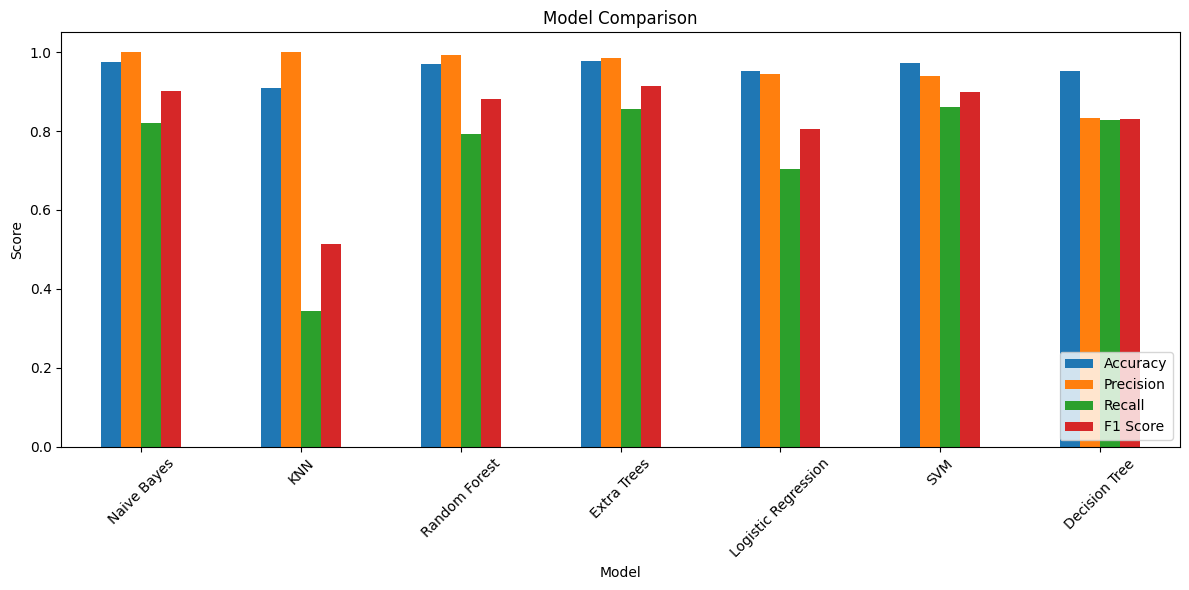

In [19]:
results_df = pd.DataFrame(results).sort_values(by='Precision', ascending=False)
print(results_df)

plt.figure(figsize=(12,6))
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']].plot(kind='bar', figsize=(12,6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [20]:
# Pick best model based on precision (important for spam — avoid false positives)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"Best Model: {best_model_name}")

pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(best_model, open('model.pkl', 'wb'))

# Download to your machine
from google.colab import files
files.download('vectorizer.pkl')
files.download('model.pkl')

Best Model: Naive Bayes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
def predict_message(message):
    transformed_msg = transform_text(message)
    vector_input = tfidf.transform([transformed_msg]).toarray()
    result = best_model.predict(vector_input)[0]
    proba = best_model.predict_proba(vector_input)[0] if hasattr(best_model, 'predict_proba') else None

    label = "SPAM" if result == 1 else "HAM (Not Spam)"
    print(f"Message: {message}")
    print(f"Prediction: {label}")
    if proba is not None:
        print(f"Confidence -> Ham: {proba[0]:.2%}, Spam: {proba[1]:.2%}")
    return label

# Test examples
predict_message("Congratulations! You won a free lottery ticket. Click here to claim now!")
predict_message("Hey, are we still meeting for lunch tomorrow?")

Message: Congratulations! You won a free lottery ticket. Click here to claim now!
Prediction: SPAM
Confidence -> Ham: 14.10%, Spam: 85.90%
Message: Hey, are we still meeting for lunch tomorrow?
Prediction: HAM (Not Spam)
Confidence -> Ham: 99.73%, Spam: 0.27%


'HAM (Not Spam)'